# EDA

This notebook is the first look at the Ames data before any modeling.

Goals:
- understand the target and what the competition metric implies
- find outliers that deserve special handling instead of blind removal
- map the missing data and decide how to impute it
- check which categorical columns are really ordered scales
- end with the concrete consequences for the modeling setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
ACCENT = "#2a78d6"
RAMP = ["#9ec5f4", "#5598e7", "#256abf", "#104281"]

plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "sans-serif",
    "text.color": INK,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": MUTED,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
})

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
target = "SalePrice"
y = train_df[target]

train_df.shape, test_df.shape

((1460, 81), (1459, 80))

## 1. The target and the metric

The competition scores RMSE on the log of the sale price, so errors are relative: being 20 percent off on a cheap house costs as much as being 20 percent off on an expensive one.

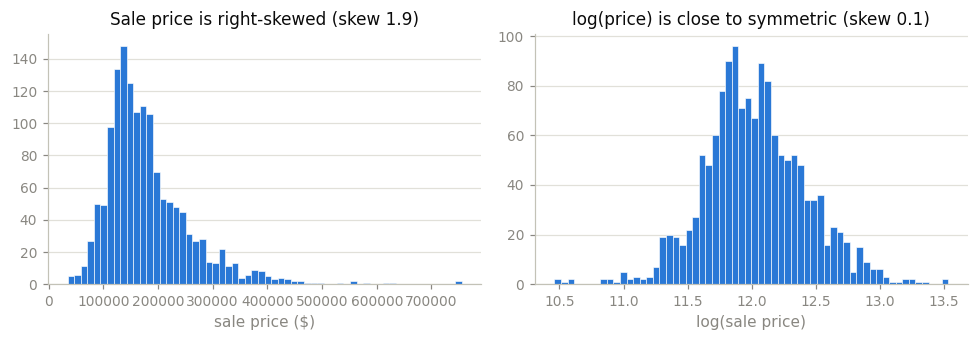

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].hist(y, bins=60, color=ACCENT, edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Sale price is right-skewed (skew {y.skew():.1f})")
axes[0].set_xlabel("sale price ($)")

axes[1].hist(np.log(y), bins=60, color=ACCENT, edgecolor="white", linewidth=0.4)
axes[1].set_title(f"log(price) is close to symmetric (skew {np.log(y).skew():.1f})")
axes[1].set_xlabel("log(sale price)")

for ax in axes:
    ax.grid(axis="x", visible=False)
fig.tight_layout()

The raw target is heavily right-skewed (skew 1.9); its log is nearly symmetric (skew 0.1). Since the metric lives in log space, all validation in this project uses log RMSE, and validation splits are stratified by log-price decile so every split sees the full price range instead of an accidental slice of it.

## 2. Living area and the two broken points

`GrLivArea` is the strongest size signal, so anything odd here matters more than an outlier in a minor column.

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
523,524,4676,184750,10,Partial
691,692,4316,755000,10,Normal
1182,1183,4476,745000,10,Abnorml
1298,1299,5642,160000,10,Partial


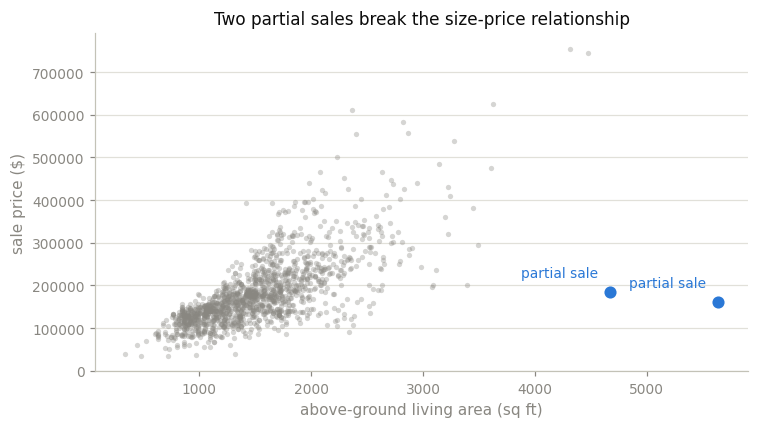

In [3]:
outlier_mask = (train_df["GrLivArea"] > 4000) & (y < 300000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(train_df.loc[~outlier_mask, "GrLivArea"], y[~outlier_mask],
           s=12, color=MUTED, alpha=0.35, linewidths=0)
ax.scatter(train_df.loc[outlier_mask, "GrLivArea"], y[outlier_mask],
           s=48, color=ACCENT, zorder=3)
for _, row in train_df.loc[outlier_mask].iterrows():
    ax.annotate("partial sale", (row["GrLivArea"], row[target]),
                textcoords="offset points", xytext=(-8, 10),
                ha="right", fontsize=9, color=ACCENT)
ax.set_title("Two partial sales break the size-price relationship")
ax.set_xlabel("above-ground living area (sq ft)")
ax.set_ylabel("sale price ($)")
ax.grid(axis="x", visible=False)
fig.tight_layout()

train_df.loc[train_df["GrLivArea"] > 4000, ["Id", "GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]]

Four houses have more than 4,000 sq ft of living area. Two sold for around $750k, which is what the trend predicts. The other two (Id 524 and 1299) sold for under $200k, and both are `Partial` sales: the house was not finished when the deal closed, so the price does not describe the house the features describe. I drop these two rows and nothing else. Every other extreme point follows the trend and stays in.

## 3. Missing data

19 columns contain missing values, but the pattern matters more than the count.

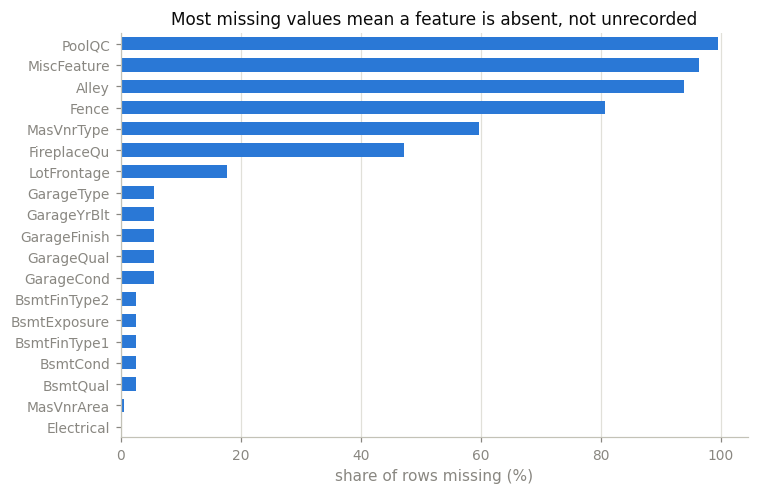

In [4]:
missing_share = train_df.isna().mean().loc[lambda s: s > 0].sort_values() * 100

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(missing_share.index, missing_share.values, height=0.62, color=ACCENT)
ax.set_title("Most missing values mean a feature is absent, not unrecorded")
ax.set_xlabel("share of rows missing (%)")
ax.grid(axis="y", visible=False)
ax.margins(y=0.01)
fig.tight_layout()

The heavy hitters are `PoolQC` (99.5 percent), `MiscFeature`, `Alley`, `Fence` and `FireplaceQu`: these are missing because the house has no pool, no alley, no fence, no fireplace. That is information, not noise. Consequences:

- categorical columns get an explicit `Missing` category instead of being imputed away
- numeric columns are median-imputed
- for `LotFrontage`, `MasVnrArea` and `GarageYrBlt` the fact that the value was missing gets its own indicator column, since absence itself carries signal

## 4. Ordered scales hiding in the categoricals

43 of the 79 feature columns are text. Many of them are not free-form categories but graded scales: `Po` (poor), `Fa` (fair), `TA` (typical), `Gd` (good), `Ex` (excellent).

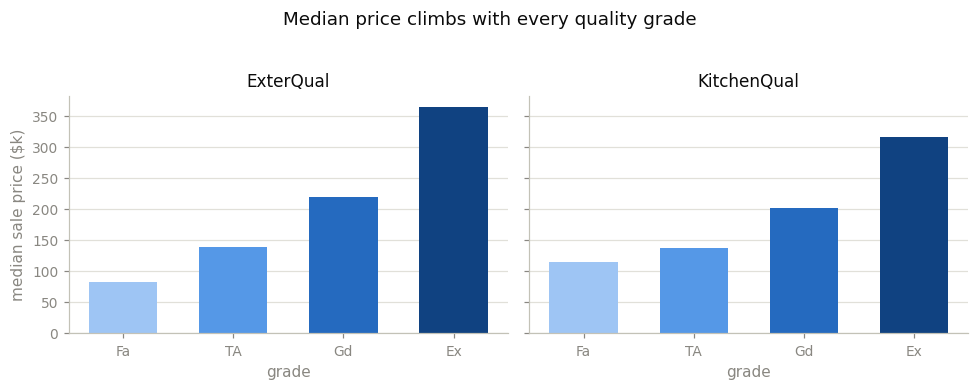

In [5]:
quality_order = ["Fa", "TA", "Gd", "Ex"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, col in zip(axes, ["ExterQual", "KitchenQual"]):
    medians = train_df.groupby(col)[target].median().reindex(quality_order) / 1000
    ax.bar(quality_order, medians.values, width=0.62, color=RAMP)
    ax.set_title(col)
    ax.set_xlabel("grade")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("median sale price ($k)")
fig.suptitle("Median price climbs with every quality grade", y=1.03)
fig.tight_layout()

The ladder is monotone: for exterior quality the median moves from $82k (`Fa`) through $139k (`TA`) and $220k (`Gd`) to $365k (`Ex`). More than twenty columns share this kind of ordered scale (`BsmtQual`, `HeatingQC`, `FireplaceQu`, `GarageFinish`, `Functional` and so on). One-hot encoding throws the order away and splinters each scale into isolated indicator columns. Mapping them to ordinal integers keeps the ranking in a single column and is the most obvious representation experiment this dataset offers.

## 5. Skewed size features

The same skew that affects the target affects the size columns.

In [6]:
numeric_skew = (
    train_df.drop(columns=["Id", target])
    .select_dtypes(include="number")
    .skew()
    .sort_values(ascending=False)
)
numeric_skew.head(12).to_frame("skew").round(2)

,skew
MiscVal,24.48
PoolArea,14.83
LotArea,12.21
3SsnPorch,10.30
LowQualFinSF,9.01
KitchenAbvGr,4.49
BsmtFinSF2,4.26
ScreenPorch,4.12
BsmtHalfBath,4.10
EnclosedPorch,3.09


`LotArea` (skew 12.2), the porch and pool areas and the second-tier basement columns all have long right tails, and the core size columns (`GrLivArea`, `LotFrontage`) are skewed too, just less extremely. Tree models are rank-based and in principle indifferent to monotone transforms, but a `log1p` copy of a heavy-tailed column changes how split points are spent along its range, so these columns are the natural candidates for a focused log-transform experiment later.

## 6. What drives the price

A last orientation check before modeling: which numeric columns correlate most with log price.

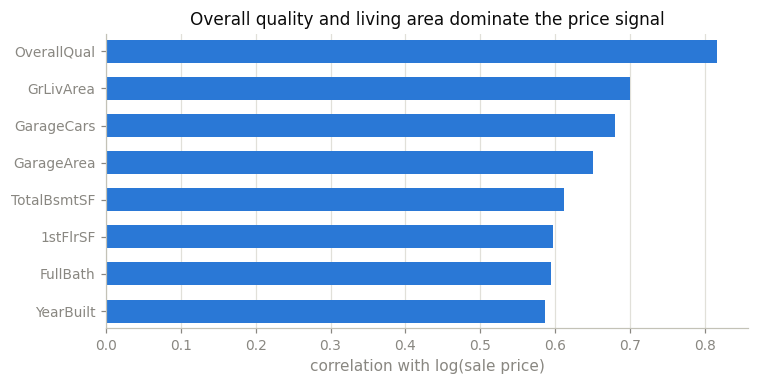

In [7]:
top_corr = (
    train_df.select_dtypes(include="number")
    .drop(columns=["Id", target])
    .corrwith(np.log(y))
    .sort_values(ascending=False)
    .head(8)
)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(top_corr.index[::-1], top_corr.values[::-1], height=0.62, color=ACCENT)
ax.set_title("Overall quality and living area dominate the price signal")
ax.set_xlabel("correlation with log(sale price)")
ax.grid(axis="y", visible=False)
ax.margins(y=0.02)
fig.tight_layout()

`OverallQual` (0.82) and `GrLivArea` (0.70) tower over everything else, followed by the garage and basement sizes. Quality and size also plainly interact: an extra square foot is worth more in a well-built house. That makes quality-times-size interaction features and additive size composites (total square footage across floors and basement) worth building.

## 7. Consequences for the setup

What the sections above dictate for everything that follows:

1. **Metric and splits.** All local evaluation uses log RMSE, and every validation split is stratified by log-price decile.
2. **Outliers.** Drop exactly two rows: the partial sales with more than 4,000 sq ft and prices under $300k. Keep every other extreme point.
3. **Imputation.** `Missing` as an explicit category for categoricals, medians for numerics, plus was-missing indicator columns for `LotFrontage`, `MasVnrArea` and `GarageYrBlt`.
4. **Representation experiments, in order of expected value:** ordinal encodings for the graded quality scales, quality-times-size interactions and size composites, and focused `log1p` copies of the heavy-tailed size columns.

The sprint notebooks (01 to 05) work through that list one controlled experiment at a time.